In [1]:
install.packages("dplyr")
install.packages("ggplot2")
install.packages("scales")
install.packages("lubridate")
install.packages("stringr")

library(dplyr)
library(ggplot2)
library(scales)
library(lubridate)
library(stringr)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




In [2]:
orders <- read.csv("orders.csv")
deliveries <- read.csv("deliveries.csv")
customers <- read.csv("customers.csv")
drivers <- read.csv("drivers.csv")
vehicles <- read.csv("vehicles.csv")
hubs <- read.csv("hubs.csv")
incidents <- read.csv("incidents.csv")
complaints <- read.csv("complaints.csv")
app_events <- read.csv("app_events.csv")

cat("R analytics files loaded successfully")

R analytics files loaded successfully

In [3]:
clean_zone <- function(x) {
  str_to_title(trimws(tolower(x)))
}

orders$pickup_zone <- clean_zone(orders$pickup_zone)
orders$dropoff_zone <- clean_zone(orders$dropoff_zone)
customers$home_zone <- clean_zone(customers$home_zone)
drivers$base_zone <- clean_zone(drivers$base_zone)
vehicles$assigned_zone <- clean_zone(vehicles$assigned_zone)
app_events$zone_context <- clean_zone(app_events$zone_context)

cat("Zone names cleaned successfully")

Zone names cleaned successfully

In [4]:
deliveries$dispatch_time <- as.POSIXct(deliveries$dispatch_time)
deliveries$delivery_completed_at <- as.POSIXct(deliveries$delivery_completed_at)

deliveries$duration_hours <- as.numeric(
  difftime(deliveries$delivery_completed_at, deliveries$dispatch_time, units = "hours")
)

deliveries$is_delayed <- ifelse(deliveries$delivery_status == "Delayed", 1, 0)
deliveries$is_failed <- ifelse(deliveries$delivery_status == "Failed", 1, 0)
deliveries$is_problem <- ifelse(deliveries$delivery_status %in% c("Delayed", "Failed"), 1, 0)

deliveries$cost_per_km <- deliveries$fuel_or_charge_cost / deliveries$route_distance_km

cat("Feature engineering completed")

ERROR: Error in as.POSIXlt.character(x, tz, ...): character string is not in a standard unambiguous format


In [5]:
deliveries$dispatch_time <- as.POSIXct(deliveries$dispatch_time, format="%Y-%m-%d %H:%M:%S", tz="UTC")
deliveries$delivery_completed_at <- as.POSIXct(deliveries$delivery_completed_at, format="%Y-%m-%d %H:%M:%S", tz="UTC")

In [6]:
deliveries$duration_hours <- as.numeric(
  difftime(deliveries$delivery_completed_at, deliveries$dispatch_time, units = "hours")
)

deliveries$is_delayed <- ifelse(deliveries$delivery_status == "Delayed", 1, 0)
deliveries$is_failed <- ifelse(deliveries$delivery_status == "Failed", 1, 0)
deliveries$is_problem <- ifelse(deliveries$delivery_status %in% c("Delayed", "Failed"), 1, 0)

deliveries$cost_per_km <- deliveries$fuel_or_charge_cost / deliveries$route_distance_km

In [7]:
summary_stats <- deliveries %>%
  summarise(
    total_deliveries = n(),
    average_distance_km = round(mean(route_distance_km, na.rm = TRUE), 2),
    average_customer_rating = round(mean(customer_rating_post_delivery, na.rm = TRUE), 2),
    average_fuel_cost = round(mean(fuel_or_charge_cost, na.rm = TRUE), 2),
    average_route_overrides = round(mean(manual_route_override_count, na.rm = TRUE), 2),
    delay_rate_pct = round(mean(is_delayed, na.rm = TRUE) * 100, 2),
    failure_rate_pct = round(mean(is_failed, na.rm = TRUE) * 100, 2),
    problem_rate_pct = round(mean(is_problem, na.rm = TRUE) * 100, 2)
  )

print(summary_stats)

  total_deliveries average_distance_km average_customer_rating
1              950               13.91                    3.86
  average_fuel_cost average_route_overrides delay_rate_pct failure_rate_pct
1             12.84                    0.97          21.26            13.89
  problem_rate_pct
1            35.16


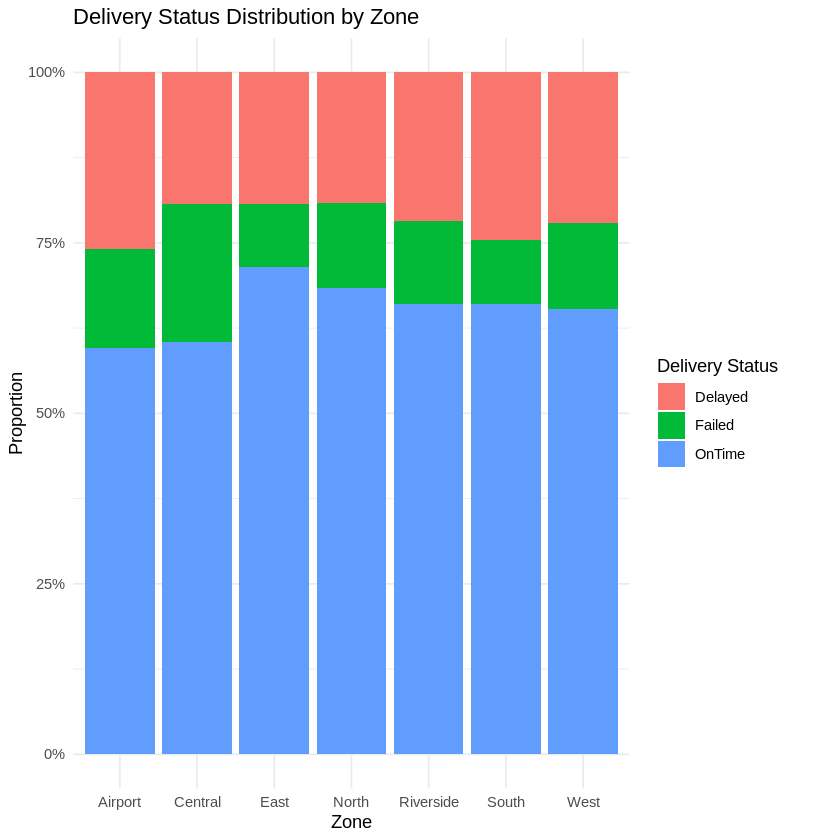

In [8]:
del_zone <- deliveries %>%
  left_join(hubs, by = "hub_id")

ggplot(del_zone, aes(x = zone, fill = delivery_status)) +
  geom_bar(position = "fill") +
  scale_y_continuous(labels = percent_format()) +
  labs(
    title = "Delivery Status Distribution by Zone",
    x = "Zone",
    y = "Proportion",
    fill = "Delivery Status"
  ) +
  theme_minimal()

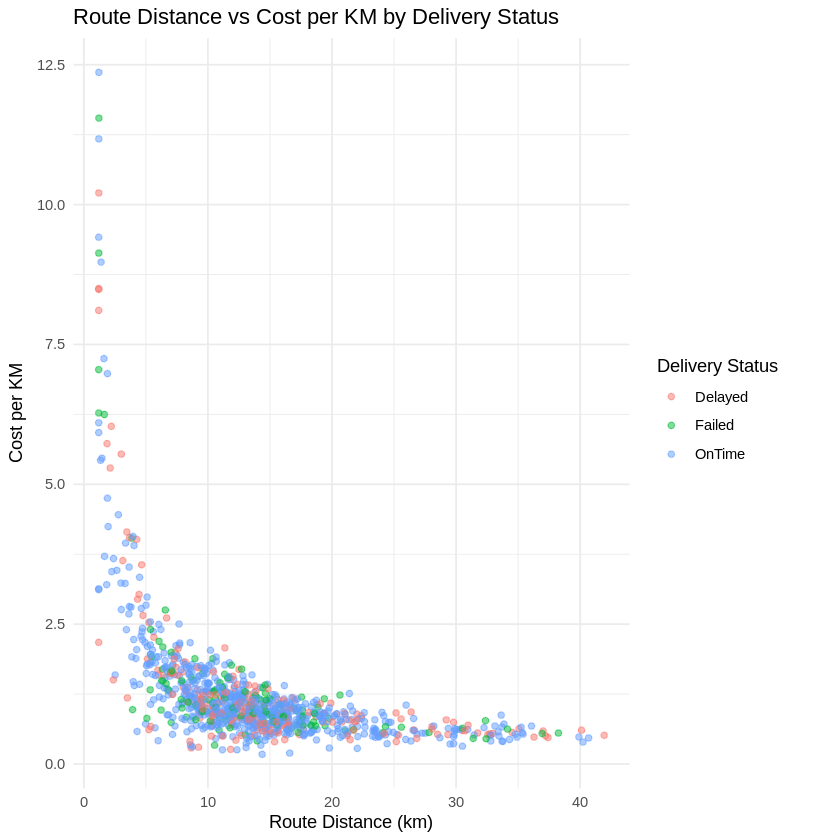

In [9]:
ggplot(deliveries, aes(x = route_distance_km, y = cost_per_km, color = delivery_status)) +
  geom_point(alpha = 0.5) +
  labs(
    title = "Route Distance vs Cost per KM by Delivery Status",
    x = "Route Distance (km)",
    y = "Cost per KM",
    color = "Delivery Status"
  ) +
  theme_minimal()

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


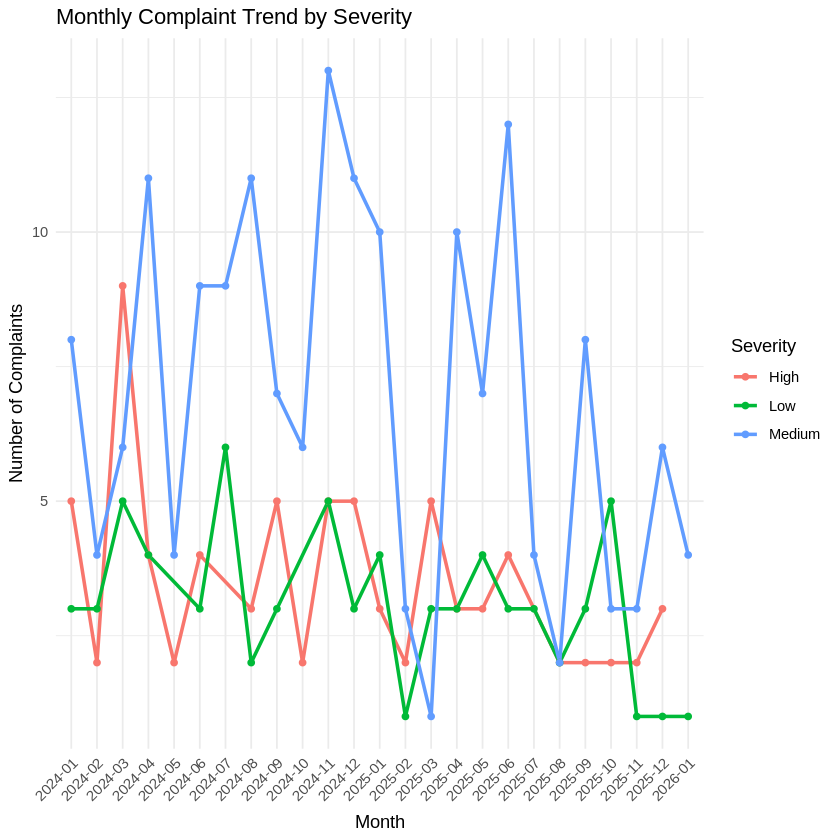

In [10]:
complaints$created_at <- as.Date(complaints$created_at)

complaint_trend <- complaints %>%
  filter(!is.na(created_at)) %>%
  mutate(month = format(created_at, "%Y-%m")) %>%
  group_by(month, severity) %>%
  summarise(count = n(), .groups = "drop")

ggplot(complaint_trend, aes(x = month, y = count, color = severity, group = severity)) +
  geom_line(size = 1) +
  geom_point() +
  labs(
    title = "Monthly Complaint Trend by Severity",
    x = "Month",
    y = "Number of Complaints",
    color = "Severity"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

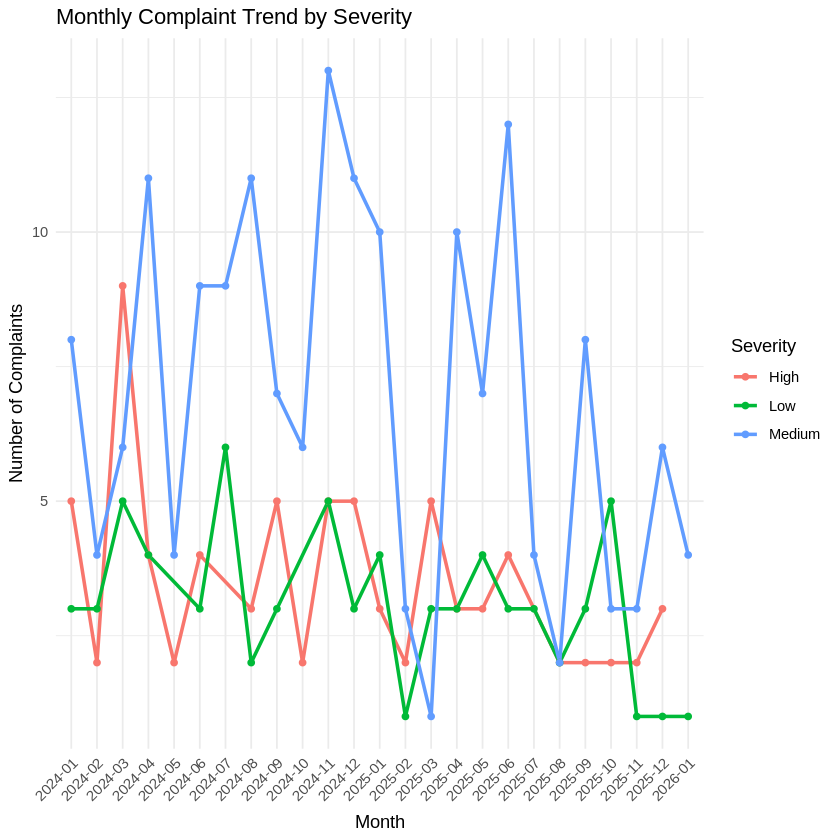

In [11]:
ggplot(complaint_trend, aes(x = month, y = count, color = severity, group = severity)) +
  geom_line(linewidth = 1) +
  geom_point() +
  labs(
    title = "Monthly Complaint Trend by Severity",
    x = "Month",
    y = "Number of Complaints",
    color = "Severity"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 14 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_point()`).”


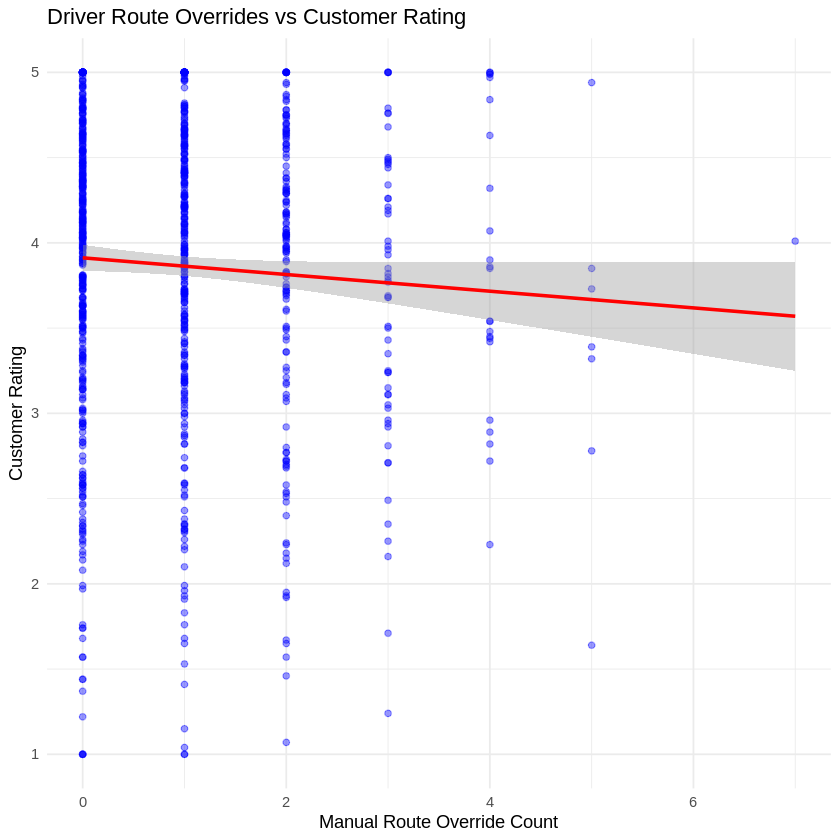

In [12]:
ggplot(deliveries, aes(x = manual_route_override_count, y = customer_rating_post_delivery)) +
  geom_point(alpha = 0.4, color = "blue") +
  geom_smooth(method = "lm", color = "red") +
  labs(
    title = "Driver Route Overrides vs Customer Rating",
    x = "Manual Route Override Count",
    y = "Customer Rating"
  ) +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


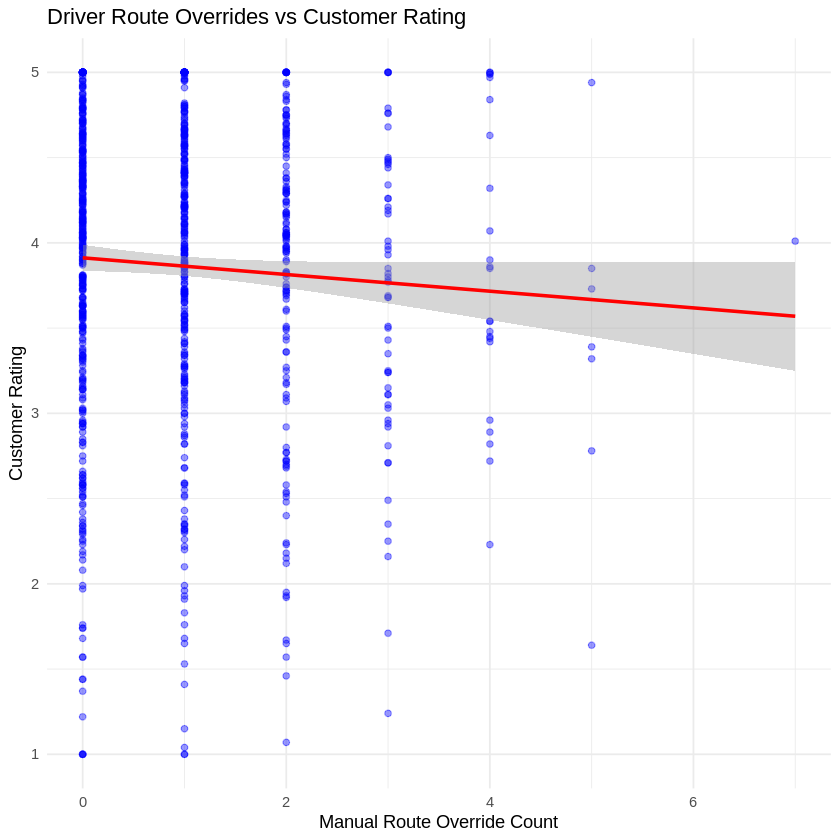

In [13]:
clean_driver_data <- deliveries %>%
  filter(!is.na(manual_route_override_count), !is.na(customer_rating_post_delivery))

ggplot(clean_driver_data, aes(x = manual_route_override_count, y = customer_rating_post_delivery)) +
  geom_point(alpha = 0.4, color = "blue") +
  geom_smooth(method = "lm", color = "red") +
  labs(
    title = "Driver Route Overrides vs Customer Rating",
    x = "Manual Route Override Count",
    y = "Customer Rating"
  ) +
  theme_minimal()